<a href="https://colab.research.google.com/github/tsilva/aiml-notebooks/blob/main/gymnasium/001-solving-cartpole_v1-with-reinforce.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Solving CartPole-v1 with REINFORCE 🤖🎮

This notebook solves the [Gymnasium CartPole-v1](https://gymnasium.farama.org/environments/classic_control/cart_pole/) environment using **REINFORCE** (Vanilla Policy Gradient) 🎮. **REINFORCE** is:

- **Policy-based:** Learns a policy directly, unlike value-based methods (e.g., **DQN**). 📈
- **On-policy:** The policy being learned interacts with the environment. 🌍
- **Model-free:** Requires no knowledge of environment dynamics. ❓
- **Monte Carlo:** Updates the policy at the end of an episode, unlike **Temporal Difference (TD)** methods. ⏳

## Setup 🛠️

First, let's install the necessary tools: 🛠️✨

In [9]:
!pip install gymnasium # The gymnasium environment
!pip install tsilva-notebook-utils # Personal utils to help with notebook authoring

Here are the key settings we'll use. 🔑 You can explore their meanings later 📖 after completing the notebook 📝 to improve your results. 📈

In [10]:
ENVIRONMENT_ID = "CartPole-v1" # The environment we want to solve
DISCOUNT_FACTOR = 0.99  # Discount factor controls how much we value future rewards
HIDDEN_SIZE = 128  # Neural network hidden layer size (128 gives enough capacity without overfitting)
LEARNING_RATE = 0.002  # Learning rate for optimizer (0.002 is a safe middle ground for small networks)
N_TRAIN_EPISODES = 5_000  # Total training episodes (5k should be more than enough)
AVERAGE_REWARD_WINDOW = 50  # Episodes required for calculating average reward

## Inspect Environment 🔍🌍

Set up the environment 🌍 and take a look 👀:

In [11]:
import gymnasium as gym
env = gym.make(ENVIRONMENT_ID, render_mode="rgb_array")
env.observation_space.shape, env.action_space

((4,), Discrete(2))

Observations (states) consist of `4` numbers 🔢, while actions are `0` or `1` ⚖️. The [docs](https://gymnasium.farama.org/environments/classic_control/cart_pole/) detail these numbers 📚, but it's not crucial since the reinforcement learning algorithm can solve the environment regardless 💪.

Let's check what is the reward threshold for this environment to be considered as solved:

In [12]:
AVERAGE_REWARD_THRESHOLD = env.spec.reward_threshold
AVERAGE_REWARD_THRESHOLD

475.0

If we average the cumulative reward for a significant number of episodes, and it's above the average reward threshold defined above, we can consider the episode as solved.

Let's run the environment for one episode 🎮 using a random policy to observe its behavior 👀:

In [13]:
import numpy as np
from tsilva_notebook_utils.video import render_video

# Define random policy
policy = lambda state: env.action_space.sample()

# Reset environment
state, _ = env.reset()

# Run environment step by step until
# it communicates it has finished
rewards = []
frames = []
done = False
while not done:
    # Render current state and collect frame
    frame = env.render()
    frames.append(frame)

    # Get next action from policy
    action = policy(state)

    # Execute action in environment
    next_state, reward, terminated, truncated, _ = env.step(action)

    # Determine if the environment
    # has finished (eg: pole fell,
    # cartpole went off the screen)
    done = terminated or truncated
    state = next_state

    # Collect reward
    rewards.append(reward)

# Log total reward
print(f"Sample rewards: {rewards[:5] + rewards[:-5]}")
print(f"Total Reward: {np.array(rewards).sum()}")

# Render collected environment frames as video
render_video(frames)

Sample rewards: [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
Total Reward: 14.0


Spoiler: it's bad. 😟 The pole falls quickly because random actions aren't sufficient. You earn a `1.0` reward per step until it crashes, and to win, you must last **500** steps. ⏳ Now that we've observed the poor performance of a random policy, let's explore how **REINFORCE** can train a more effective one. 🚀

## Intuitions on REINFORCE 🤔✨

Imagine playing **rock-paper-scissors** ✊📄✂️ against a friend. Each round, you choose based on their last move. If they played **rock** 🪨, that's your **state**, and your confidence levels are:  

- **50%** for paper 📄  
- **30%** for rock 🪨  
- **20%** for scissors ✂️  

You choose one, they play again, and you score:  

- **+1** for a win 🏆  
- **0** for a tie 🤝  
- **-1** for a loss ❌  

After **5 hands** ✋, you total your score—perhaps **+2** from winning twice, tying once, and losing twice. **REINFORCE** uses this score to adjust your instincts for next time, even if not every choice was optimal.  

With a total of **+2**, you reflect on your moves: *“These picks likely helped.”* If you chose **paper** 📄 with **50% confidence** after they played **rock** 🪨, you increase that confidence. If you picked **rock** 🪨 at **70%** after they played **scissors** ✂️, you adjust it slightly. If your total is **-3**, you reduce confidence in weaker choices, like **20% for scissors** ✂️, while adjusting confident ones less.  

Your friend has biases:  

- They may **favor rock after winning** 🪨🏆  
- They might **repeat scissors when nervous** ✂️😰  

You can't pinpoint which moves were effective, but the final score suggests: *"I did well, so these were smart guesses."* The strategy is to **increase confidence** for high-scoring rounds and **decrease it** for low ones, improving your instincts. Over time, you notice their habits—like playing **paper** 📄 more after showing rock 🪨—and your scores improve. **REINFORCE** guides you, refining your choices and turning instincts into a strategy that **exploits their quirks**.

## Create Policy Model 📄✨

To train a policy with **REINFORCE** 🎮, we need a model that adjusts based on policy performance (episode reward) 🏆. **Neural Networks** 🧠 with **Backpropagation** 🔄 and **Gradient Descent** 📉 are suitable for this. By defining a loss function that increases with poor performance 📈, these techniques adjust the model’s parameters to reinforce good actions 👍 and decrease bad ones 👎 in future episodes.

Let's create the **Neural Network** 🤖 to represent our policy 📜:

In [14]:
import torch
import torch.nn as nn

class PolicyNetwork(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(PolicyNetwork, self).__init__()

        # Create a multilayer perceptron with just one hidden layer
        self.net = nn.Sequential(
            nn.Linear(state_dim, HIDDEN_SIZE), # Hidden layer (observation_space_size, hidden_layer_size)
            nn.ReLU(), # ReLU activation (for be able to model a non-linear functions)
            nn.Linear(HIDDEN_SIZE, action_dim) # Output layer (hidden_layer_size, action_space_size)
        )

    def forward(self, x):
        return self.net(x)

input_size = env.observation_space.shape[0]
output_size = env.action_space.n
model = PolicyNetwork(input_size, output_size)
model

PolicyNetwork(
  (net): Sequential(
    (0): Linear(in_features=4, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=2, bias=True)
  )
)

This environment features a low-dimensional continuous observation space 🌌 and a small discrete action space 🎮, allowing our **Neural Network** 🤖 to be a simple **Multilayer Perceptron** 🧠 with one hidden layer.  

It takes **4** observation values as input 🔍 and outputs **2** logits 📊, indicating the quality of each action in a given state.  

Let's test it by running an observation through the network 🚀:

In [15]:
with torch.no_grad(): # Don't track gradients during inference
  action_logits = model(torch.tensor(state)) # State is a numpy object, needs to be converted to tensor first
action_logits

tensor([-0.2715,  0.2216])

The higher the logit for an action 📈, the more confident the model is that the action should be taken in that state 🤔. However, since the model is untrained 🚫, these logits are currently random 🎲.

Logits alone aren't ideal. While they indicate the "best" action, we don't always want the highest score, as the model doesn't initially know the best actions. Instead, we want to **sample** from possible actions, favoring those the model is more confident in. 🎲

This approach balances **exploration and exploitation**:  
- It allows the model to try less-favored actions, potentially leading to **unexpectedly high rewards** 🎉 and further learning.  
- It ensures the model **leans toward the best-known actions** while refining its understanding over time. 📈

To sample actions based on the model's confidence 🤖, we convert logits into a probability distribution 📊 (values from `0.0` to `1.0` that sum to `1.0`) using the `softmax()` function:

In [16]:
action_probs = torch.softmax(action_logits, dim=-1) # Dim = -1 means the last dimension of the tensor, Dim = 0 would also work in this case
action_probs, action_probs.sum()

(tensor([0.3792, 0.6208]), tensor(1.))

Now, let's sample an action: 🎬✨

In [17]:
action = torch.multinomial(action_probs, 1).item() # Sample 1 action from the probability distribution
action

1

You can run the cell above multiple times 🔄 to get different actions 🎭. The action with the highest logit 📈 will appear more frequently 🔍.

## Model the Loss Function 📉✨

When training a policy with **REINFORCE** 🎮, the policy loss influences action choice improvements.

We need a **loss function** ⚖️ that optimizes **episode rewards** 🏆 while promoting **confident and accurate predictions**. It should:

- **Encourage** high-confidence **correct** predictions ✅  
- **Penalize** high-confidence **incorrect** predictions ❌  
- **Penalize** low-confidence **correct** predictions ⚠️  

Consider the **rock-paper-scissors** ✊✋🖐️ game: if your friend plays **rock** 🪨, and your confidence levels are:

- **50%** for paper 📄  
- **30%** for rock 🪨  
- **20%** for scissors ✂️  

After playing five hands, you might score **+2** from a couple of wins. If you were **90% sure** of “paper” 📄 after their rock 🪨 and won, you’d think, *“Lock that in next time.”* 🔒 Conversely, if you were only **10% sure** of “scissors” ✂️ after their paper 📄 and won, you’d feel, *“Nice, but that was a fluke.”* 🤷‍♂️  

If you end up with **-3**, a confident **90% in “rock”** 🪨 that failed feels worse than a shaky **10% in “paper”** 📄 that lost. We adjust your intuition based on the final score—rewarding the good 🌟, penalizing the bad ⚠️, and guiding our optimizer on what to pursue.

Now, let's design the loss function step-by-step: 🛠️

**Step 1: Compute Returns** 📈

To construct the loss function, compute the return for each step as the immediate reward 💰 plus discounted future rewards. Distant rewards should contribute less to the total return due to their uncertainty. 🌌

**Step 2: Normalize** ✨

Normalize returns by subtracting the mean $\mu$ 📉 and dividing by the standard deviation $\sigma$ 📊. This keeps training stable ⚖️ by emphasizing relative performance over varying absolute reward scales. 🌟

**Step 3: Scale with Log Probs** 📈

We scale returns by the policy's confidence using logarithm of probabilities, $\log \pi(a|s)$, instead of raw probabilities. Logarithms amplify small confidence differences—low-confidence actions yield large negative logs, reducing flukes' impact—while enhancing optimization smoothness. Here's how it works:

- **Big return, high confidence:** Raw return `100` normalizes to `+2`, with `90%` confidence ($\log(0.9) \approx -0.1$). Loss term: $+2 \times -0.1 = -0.2$. The policy is nudged to reinforce this trusted action. 👍
- **Big return, low confidence:** Raw return `100` normalizes to `+2`, with `0.1%` confidence ($\log(0.001) \approx -6.9$). Term: $+2 \times -6.9 = -13.8$. The large negative log reduces the fluke's impact, preventing overreaction. 🚫
- **Bad return, low confidence:** Raw return `-50` normalizes to `-1`, confidence `0.1%` ($\log(0.001) \approx -6.9$). Term: $-1 \times -6.9 = +6.9$. The update is small, reflecting the action's rarity. 🔍
- **Bad return, high confidence:** Raw return `-50` normalizes to `-1`, confidence `90%` ($\log(0.9) \approx -0.1$). Term: $-1 \times -0.1 = +0.1$. The policy adjusts more, reconsidering a trusted action that resulted in a poor outcome. ⚖️

**Step 4: Calculate the Loss** 📉

After scaling down the returns, calculate their mean, which we aim to maximize. Since **Gradient Descent** 🔄 is commonly used in **Neural Networks** 🧠, we negate this value so that its maximum corresponds to a high-magnitude negative loss. ⚠️

Now that we know how to build our loss function, let's proceed step by step. 🛠️ First, we need to collect the rewards 🎉 and action log probabilities 📊 for an episode:

In [18]:
def run_episode(env, policy, train_mode=False):
    # Reset the environment
    state, _ = env.reset()

    # Run environment until it
    # communicates that it has finished
    done = False
    rewards = []
    action_logprobs = []
    frames = []
    while not done:
        # Render frame
        frame = env.render()
        frames.append(frame)

        # Predict action probabilities using the model
        with torch.no_grad() if not train_mode else torch.enable_grad():
            action_logits = policy(torch.tensor(state))
            action_probs = torch.softmax(action_logits, dim=-1)
            action = torch.multinomial(action_probs, 1).item()

        # Collect action log probabilities
        action_prob = action_probs[action]
        action_log_prob = torch.log(action_prob)
        action_logprobs.append(action_log_prob)

        # Step the environment
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        # Store reward and update state
        rewards.append(reward)
        state = next_state

    return rewards, action_logprobs, frames

# Run an episode
rewards, action_logprobs, _ = run_episode(env, model)
rewards[:5], action_logprobs[:5]

([1.0, 1.0, 1.0, 1.0, 1.0],
 [tensor(-0.8143),
  tensor(-0.6145),
  tensor(-0.8147),
  tensor(-0.7789),
  tensor(-0.7606)])

Now we can calculate the returns 📈 for each step 🔢 without normalizing them yet:

In [19]:
def calculate_returns(rewards, discount_factor=DISCOUNT_FACTOR, normalize=True):
    # Initialize returns tensor (same shape as rewards)
    returns = torch.zeros(len(rewards))

    # Return for each step is the reward for that step
    # plus the discounted return for the next step
    # (calculated from last to first step)
    for t in range(len(returns)-1, -1, -1):
      returns[t] = rewards[t] + discount_factor * (returns[t+1] if t < len(returns)-1 else 0)

    # To normalize values so that they match a normal distribution
    # we only have to subtract the mean of the values and divide by
    # the standard deviation
    if normalize: returns = (returns - returns.mean()) / (returns.std() + 1e-8) # NOTE: we add a small value to std() because it can be zero when all values are the same

    # Return the returns :)
    return returns

calculate_returns(rewards, normalize=False)

tensor([12.2479, 11.3615, 10.4662,  9.5618,  8.6483,  7.7255,  6.7935,  5.8520,
         4.9010,  3.9404,  2.9701,  1.9900,  1.0000])

Earlier timesteps yield higher returns 📈 as they incorporate discounted rewards from future steps. In contrast, returns decrease 📉 throughout the episode, reaching `1.0` at the final step, reflecting only the immediate reward 🎯.

This pattern of diminishing returns may not always be linear. In this simple environment 🌱, with a consistent immediate reward of `1.0`, the progression is clear. However, in more complex environments 🌪️ with varying reward magnitudes and polarities—large or small, positive or negative—the return dynamics differ significantly.

Now let's recalculate the returns with normalization 📊✨:

In [20]:
returns = calculate_returns(rewards)
returns

tensor([ 1.5123,  1.2695,  1.0242,  0.7765,  0.5262,  0.2734,  0.0181, -0.2399,
        -0.5004, -0.7636, -1.0294, -1.2979, -1.5691])

Don't worry about negative numbers ➖; the relative scale of rewards 🎁 remains intact. What matters is the direction of the return ⬆️, not the sign.

We need to format the action log probabilities to match the returns—a 1D tensor of the same length 📏. Currently, they are stored as a list of tensors 📋. We can convert them into a single tensor by concatenating with `torch.stack()` 🔗:

In [21]:
stacked_action_logprobs = torch.stack(action_logprobs)
stacked_action_logprobs

tensor([-0.8143, -0.6145, -0.8147, -0.7789, -0.7606, -0.7439, -0.7338, -0.6603,
        -0.7313, -0.7255, -0.6658, -0.7259, -0.7189])

Let's confirm that **returns** 📈 and **action log probabilities** 📊 share the same shape:

In [22]:
returns.shape, stacked_action_logprobs.shape

(torch.Size([13]), torch.Size([13]))

They have the same shape 🔷, allowing us to scale the returns 📈:

In [23]:
scaled_returns = stacked_action_logprobs * returns
scaled_returns

tensor([-1.2316, -0.7801, -0.8344, -0.6048, -0.4002, -0.2034, -0.0133,  0.1584,
         0.3659,  0.5540,  0.6854,  0.9422,  1.1281])

With the scaled returns 📈, we can now calculate the episode's mean return 📊, which our policy aims to maximize 🎯:

In [24]:
mean_return = torch.mean(scaled_returns)
mean_return

tensor(-0.0180)

Finally, we negate the mean return to obtain the policy loss. **Gradient descent** aims to minimize loss, which correlates with improving our policy 📈. By negating the mean return, we create a term that, when minimized, enhances the mean return 🌟.

In [25]:
policy_loss = -1.0 * mean_return
policy_loss

tensor(0.0180)

Let's create a loss calculation function for use during training: 📊🤖

In [26]:
def calculate_policy_loss(rewards, action_logprobs):
    returns = calculate_returns(rewards)
    stacked_action_logprobs = torch.stack(action_logprobs)
    scaled_returns = stacked_action_logprobs * returns
    mean_return = torch.mean(scaled_returns)
    policy_loss = -mean_return
    return policy_loss

calculate_policy_loss(rewards, action_logprobs)

tensor(0.0180)

Now that we can calculate the loss 📉, we will run the training loop 🔄 and adjust the policy 📝 using backpropagation 🔙 and gradient descent optimization ⬇️.

## Train Policy 🚆📜

In [27]:
import time
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from tsilva_notebook_utils.video import render_video

def train(model, n_episodes=N_TRAIN_EPISODES):
  # Set the model in training mode
  model.train()

  # Create the optimizer that will adjust the policy
  # model's parameters to minimize policy loss
  optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

  # Run training for N episodes
  start = time.time()
  episode_rewards = []
  for episode in range(N_TRAIN_EPISODES):
      # Run the episode (enable train mode to track gradients)
      rewards, action_logprobs, frames = run_episode(env, model, train_mode=True)

      # Calculate the policy loss
      policy_loss = calculate_policy_loss(rewards, action_logprobs)

      # Zero out the gradients (otherwise they would
      # accumulate between optimization steps)
      optimizer.zero_grad()

      # Perform backpropagation to calculate policy model
      # parameter gradients, which inform on how to tweak
      # parameters to reduce loss, capturing both direction and scale
      policy_loss.backward()

      # Perform an optimization step, using gradients calculated
      # during backpropagation to adjust model parameters in the direction
      # that is likely to make the loss smaller (adjustment is scaled
      # down by magnitude of learning rate)
      optimizer.step()

      # Store total reward to plot at end of training
      total_reward = np.array(rewards).sum()
      episode_rewards.append(total_reward)

      # Every N episodes, calculate the average reward of those episodes,
      # if it passes a threshold, the environment is considered to be solved
      # (NOTE: we need to make sure the average is above the threshold to
      # discount for episodes where the policy was just lucky)
      if (episode + 1) % AVERAGE_REWARD_WINDOW == 0:
          avg_reward = np.mean(episode_rewards[-AVERAGE_REWARD_WINDOW:])
          print(f"Episode {episode + 1}, Avg Reward: {avg_reward}")
          if avg_reward >= AVERAGE_REWARD_THRESHOLD:
              break

  # Close environment
  env.close()

  # Print final stats
  elapsed = time.time() - start
  print(f"Environment solved in {episode} episodes ({elapsed:.2f} seconds)")

  return episode_rewards

# Train the policy model
episode_rewards = train(model)
episode_rewards[:5] + ["..."] + episode_rewards[-5:]

Episode 50, Avg Reward: 23.6
Episode 100, Avg Reward: 34.5
Episode 150, Avg Reward: 78.54
Episode 200, Avg Reward: 155.76
Episode 250, Avg Reward: 263.02
Episode 300, Avg Reward: 299.28
Episode 350, Avg Reward: 289.7
Episode 400, Avg Reward: 205.64
Episode 450, Avg Reward: 295.74
Episode 500, Avg Reward: 271.0
Episode 550, Avg Reward: 338.86
Episode 600, Avg Reward: 469.28
Episode 650, Avg Reward: 411.1
Episode 700, Avg Reward: 354.16
Episode 750, Avg Reward: 481.7
Environment solved in 749 episodes (656.25 seconds)


[20.0, 14.0, 20.0, 25.0, 44.0, '...', 500.0, 500.0, 500.0, 500.0, 500.0]

Our model is trained 🎓; let's plot the training progress 📈:

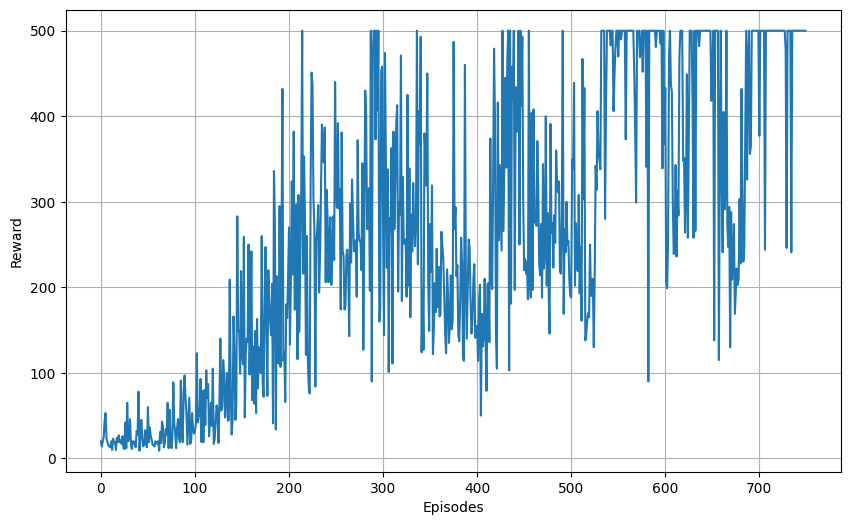

In [28]:
def plot_episode_rewards(episode_rewards):
  plt.figure(figsize=(10, 6))
  plt.xlabel('Episodes')
  plt.ylabel('Reward')
  plt.grid(True)
  plt.plot(episode_rewards)
  plt.show()

plot_episode_rewards(episode_rewards)

We stopped upon reaching our reward threshold 🎯 due to the training process's instability. Continuing could lead to suboptimal behaviors ⚠️ and performance degradation 📉. To train longer while mitigating this risk, we should save model snapshots 💾 whenever a new best reward is achieved 🏆, allowing us to revert to the best-performing version at the end of training 🔄.

## Evaluate Policy 📊📝

A good reward during training isn't sufficient; the real test is running the trained policy multiple times in the environment 🌍 to check reward consistency. Averaging these rewards 📊 is the true measure of the policy's effectiveness.

In [29]:
from IPython.display import clear_output

def evaluate(model, n_episodes=10):
    # Set the model in evaluation mode
    model.eval()

    # Run evaluation for N episodes
    episode_rewards = []
    for episode in range(n_episodes):
        rewards, action_logprobs, frames = run_episode(env, model, train_mode=True)
        episode_reward = np.array(rewards).sum()
        episode_rewards.append(episode_reward)
        print(f"Episode {episode+1} Reward: {episode_reward}")

    # Print final stats
    mean_reward = np.mean(episode_rewards)
    print(f"Mean reward over {n_episodes} episodes: {mean_reward}")

    # Return stats and frames (for rendering)
    return mean_reward, frames

_, frames = evaluate(model, n_episodes=10)
render_video(frames)

Episode 1 Reward: 500.0
Episode 2 Reward: 500.0
Episode 3 Reward: 500.0
Episode 4 Reward: 500.0
Episode 5 Reward: 500.0
Episode 6 Reward: 500.0
Episode 7 Reward: 500.0
Episode 8 Reward: 500.0
Episode 9 Reward: 500.0
Episode 10 Reward: 417.0
Mean reward over 10 episodes: 491.7


## Further Improvements 🚀✨

And we're done! 🎉 To optimize the algorithm, consider these experiments:

- **Increase `LEARNING_RATE`**: Set it to `0.01` to speed up training—observe if rewards increase faster. 🚀
- **Decrease `LEARNING_RATE`**: Lower it to `0.001` for more cautious updates—see how it stabilizes the learning curve. 📉
- **Modify `DISCOUNT_FACTOR`**: Use `0.95` to prioritize short-term rewards—plot the results to notice changes. 📊
- **Enhance `HIDDEN_SIZE`**: Raise it to `256` for a stronger network—test its performance on the pole. 🏋️‍♂️
- **Implement a baseline**: Subtract the average return from past episodes from `returns` before scaling to reduce variability. ⚖️
- **Explore different environments**: Run the codebase in similar environments like:
  - [Acrobot-v1](https://gymnasium.farama.org/environments/classic_control/acrobot/) 🤖
  - [MountainCar-v0](https://www.gymlibrary.dev/environments/classic_control/mountain_car/) ⛰️
  - [LunarLander-v3](https://www.gymlibrary.dev/environments/box2d/lunar_lander/) 🌕
  - [Blackjack-v1](https://www.gymlibrary.dev/environments/toy_text/blackjack/) ♠️
  - [FrozenLake-v1](https://www.gymlibrary.dev/environments/toy_text/frozen_lake/) ❄️

Adjust these parameters one at a time, rerun the code, and discover your optimal setup! 🔍✨